Time series forecasting involves predicting future values of a sequence of data points over time. It’s commonly used in various domains like finance, economics, supply chain management, and more.

Key Concepts in Time Series Forecasting:
Stationarity: A stationary time series has a constant mean and variance over time. Non-stationary data often needs to be made stationary through techniques like differencing or transformation.

Seasonality: Refers to patterns that repeat at regular intervals, such as monthly sales spikes.

Trend: The long-term movement in the data, which can be upward, downward, or flat.

Noise: Random variations in the data that do not follow any pattern.

Common Methods for Time Series Forecasting:
ARIMA (AutoRegressive Integrated Moving Average): Combines autoregression (AR), differencing (I), and moving averages (MA) to model time series data.

Exponential Smoothing (ETS): Models time series data with trend and seasonality components, adjusting exponentially over time.

SARIMA (Seasonal ARIMA): Extends ARIMA to handle seasonality in time series data.

Prophet: Developed by Facebook, this model is flexible and works well with missing data and outliers, making it popular for business time series forecasting.

LSTM (Long Short-Term Memory): A type of recurrent neural network (RNN) that is particularly effective in capturing dependencies in sequences, including long-term dependencies.

Steps to Build a Time Series Forecasting Model:
Data Collection: Gather the time series data you want to forecast.

Exploratory Data Analysis (EDA): Visualize and understand the patterns, trends, and seasonality in your data.

Preprocessing:

Handle missing values.
Make the series stationary if necessary.
Decompose the time series into trend, seasonality, and residual components.
Model Selection: Choose the appropriate model based on your data's characteristics.

Model Training: Split the data into training and testing sets and train the model.

Evaluation: Use metrics like Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and Mean Absolute Percentage Error (MAPE) to evaluate the model's performance.

Forecasting: Use the trained model to predict future data points.

Visualization: Visualize the forecasted values against the actual values to interpret the model’s performance.

Tools & Libraries:
Python: pandas, numpy, matplotlib, statsmodels, scikit-learn, fbprophet, tensorflow/keras (for LSTM).
R: forecast, tseries, prophet, ggplot2.

In [11]:
pip install pandas numpy matplotlib statsmodels scikit-learn prophet tensorflow


Note: you may need to restart the kernel to use updated packages.


In [12]:
#import libraries

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [13]:
# Load the AirPassengers dataset
data = sm.datasets.get_rdataset("AirPassengers").data
data.columns = ['Month', 'Passengers']

print(data.columns)

Index(['Month', 'Passengers'], dtype='object')


In [14]:
# Convert the 'Month' column to datetime format
data['Month'] = pd.to_datetime(data['Month'])

In [15]:
# Set 'Month' as the index
data.set_index('Month', inplace=True)

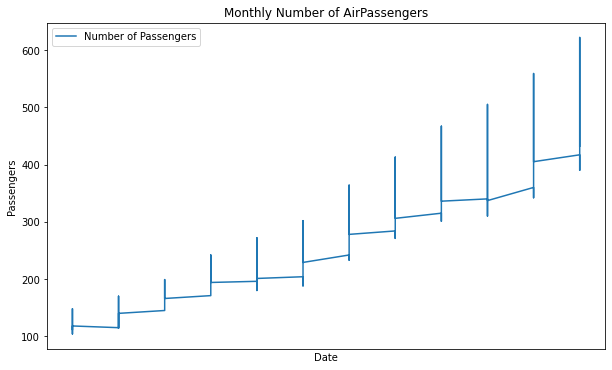

In [16]:
# Plot the dataset
plt.figure(figsize=(10, 6))
plt.plot(data['Passengers'], label='Number of Passengers')
plt.title('Monthly Number of AirPassengers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

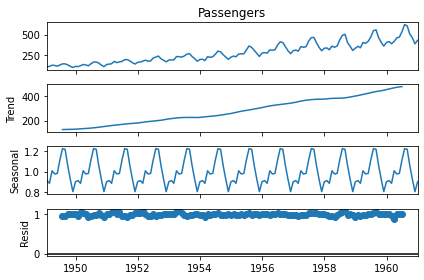

In [18]:
# Ensure the 'Month' index has a frequency set
data.index = pd.date_range(start='1949-01', end='1961-01', freq='M')

# Decompose the time series to observe trend, seasonality, and residuals
from statsmodels.tsa.seasonal import seasonal_decompose

# Now, the frequency is automatically detected, or you can specify the period
result = seasonal_decompose(data['Passengers'], model='multiplicative', period=12)
result.plot()
plt.show()


1961-01-31    489.459724
1961-02-28    513.421772
1961-03-31    523.538285
1961-04-30    505.021114
1961-05-31    481.184564
1961-06-30    471.972590
1961-07-31    473.299157
1961-08-31    482.408891
1961-09-30    491.484805
1961-10-31    494.185149
1961-11-30    491.917080
1961-12-31    487.640958
Freq: M, Name: predicted_mean, dtype: float64


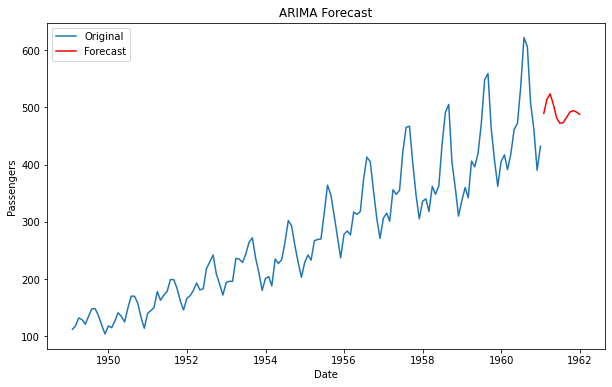

In [19]:
#ARIMA (AutoRegressive Integrated Moving Average)

from statsmodels.tsa.arima.model import ARIMA

# Fit an ARIMA model
model_arima = ARIMA(data['Passengers'], order=(5, 1, 0))
model_arima_fit = model_arima.fit()

# Make predictions
forecast_arima = model_arima_fit.forecast(steps=12)
print(forecast_arima)

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(data['Passengers'], label='Original')
plt.plot(forecast_arima, label='Forecast', color='red')
plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()


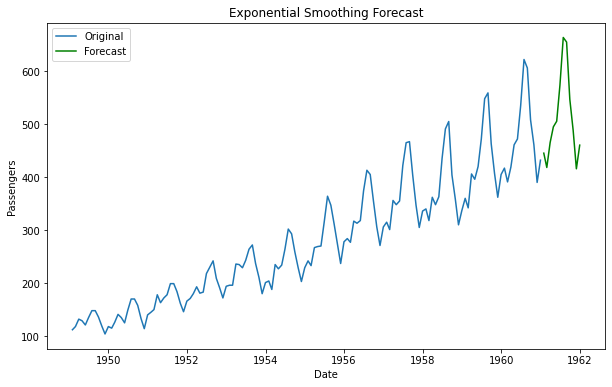

In [20]:
#Exponential Smoothing (ETS)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit the Exponential Smoothing model
model_ets = ExponentialSmoothing(data['Passengers'], trend='add', seasonal='multiplicative', seasonal_periods=12)
model_ets_fit = model_ets.fit()

# Make predictions
forecast_ets = model_ets_fit.forecast(steps=12)

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(data['Passengers'], label='Original')
plt.plot(forecast_ets, label='Forecast', color='green')
plt.title('Exponential Smoothing Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.52844D+00    |proj g|=  8.65844D-02

At iterate    5    f=  3.52337D+00    |proj g|=  3.73532D-02

At iterate   10    f=  3.51577D+00    |proj g|=  4.96157D-03

At iterate   15    f=  3.51498D+00    |proj g|=  1.98047D-03

At iterate   20    f=  3.51493D+00    |proj g|=  6.52624D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     24     28      1     0     0   5.614D-06   3.515D+00
  F =   3.5149263538352198     

CONVERG

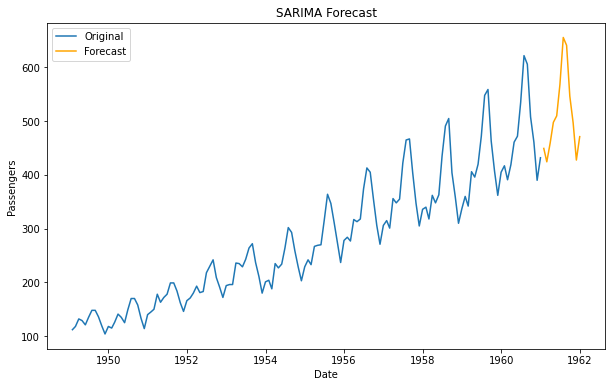

In [21]:
#SARIMA (Seasonal ARIMA)

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit a SARIMA model
model_sarima = SARIMAX(data['Passengers'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_sarima_fit = model_sarima.fit()

# Make predictions
forecast_sarima = model_sarima_fit.forecast(steps=12)

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(data['Passengers'], label='Original')
plt.plot(forecast_sarima, label='Forecast', color='orange')
plt.title('SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()


Importing plotly failed. Interactive plots will not work.
04:01:36 - cmdstanpy - INFO - Chain [1] start processing
04:01:36 - cmdstanpy - INFO - Chain [1] done processing


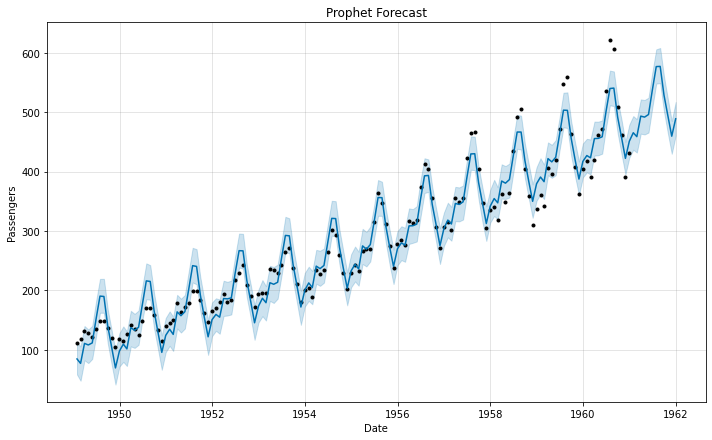

In [24]:
#Prophet

from prophet import Prophet

# Prepare the data for Prophet
df = data.reset_index()
df.columns = ['ds', 'y']

# Initialize and fit the Prophet model
model_prophet = Prophet()
model_prophet.fit(df)

# Make future predictions
future = model_prophet.make_future_dataframe(periods=12, freq='M')
forecast_prophet = model_prophet.predict(future)

# Plot the forecast
model_prophet.plot(forecast_prophet)
plt.title('Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.show()



2024-08-25 04:02:06.798205: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-25 04:02:07.033118: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-25 04:02:07.286843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-25 04:02:07.446869: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-25 04:02:07.491629: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-25 04:02:08.057117: I tensorflow/core/platform/cpu_feature_gu

Epoch 1/20


I0000 00:00:1724533331.909415   20696 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-08-25 04:02:11.910640: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/laptop-b4u31e4jnot/.pyenv/versions/3.9.5/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


102/102 - 1s - 10ms/step - loss: 0.0084
Epoch 2/20
102/102 - 0s - 3ms/step - loss: 0.0073
Epoch 3/20
102/102 - 0s - 3ms/step - loss: 0.0067
Epoch 4/20
102/102 - 0s - 2ms/step - loss: 0.0058
Epoch 5/20
102/102 - 0s - 2ms/step - loss: 0.0050
Epoch 6/20
102/102 - 0s - 2ms/step - loss: 0.0026
Epoch 7/20
102/102 - 0s - 2ms/step - loss: 0.0057
Epoch 8/20
102/102 - 0s - 2ms/step - loss: 0.0043
Epoch 9/20
102/102 - 0s - 2ms/step - loss: 0.0030
Epoch 10/20
102/102 - 0s - 2ms/step - loss: 0.0028
Epoch 11/20
102/102 - 0s - 2ms/step - loss: 0.0021
Epoch 12/20
102/102 - 0s - 3ms/step - loss: 0.0020
Epoch 13/20
102/102 - 0s - 2ms/step - loss: 0.0022
Epoch 14/20
102/102 - 0s - 2ms/step - loss: 0.0019
Epoch 15/20
102/102 - 0s - 2ms/step - loss: 0.0019
Epoch 16/20
102/102 - 0s - 2ms/step - loss: 0.0021
Epoch 17/20
102/102 - 0s - 3ms/step - loss: 0.0020
Epoch 18/20
102/102 - 0s - 2ms/step - loss: 0.0019
Epoch 19/20
102/102 - 0s - 2ms/step - loss: 0.0014
Epoch 20/20
102/102 - 0s - 3ms/step - loss: 0.0022

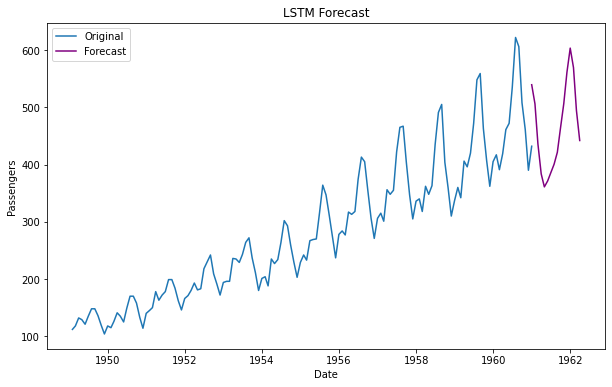

In [25]:
#LSTM (Long Short-Term Memory Network)

import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Prepare the data for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 12
X_train, Y_train = create_dataset(train, look_back)
X_test, Y_test = create_dataset(test, look_back)

# Reshape the input for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Build the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(100, input_shape=(look_back, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(loss='mean_squared_error', optimizer='adam')
model_lstm.fit(X_train, Y_train, epochs=20, batch_size=1, verbose=2)

# Make predictions
train_predict = model_lstm.predict(X_train)
test_predict = model_lstm.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Plot the LSTM forecast
plt.figure(figsize=(10, 6))
plt.plot(data['Passengers'], label='Original')
plt.plot(pd.date_range(data.index[-1], periods=len(test_predict), freq='M'), test_predict, label='Forecast', color='purple')
plt.title('LSTM Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()


The best time series model for your data depends on the characteristics of the data itself, including factors like trend, seasonality, and noise. Here’s a general guide on choosing the appropriate model:

# 1. ARIMA (AutoRegressive Integrated Moving Average)
Recommended when:

The data is stationary or can be made stationary through differencing.
There is no strong seasonal component.
The dataset has a consistent pattern over time without complex seasonality.
Use cases:

Stock prices, economic indicators, or any time series data with short-term dependencies.

# 2. SARIMA (Seasonal ARIMA)
Recommended when:

The data exhibits both trend and seasonality.
The seasonal patterns repeat at regular intervals (e.g., monthly, quarterly).
Use cases:

Sales data with yearly seasonality, monthly airline passenger data.

# 3. Exponential Smoothing (ETS)
Recommended when:

The data has a strong trend and/or seasonal pattern.
You need a model that adjusts to changes over time smoothly.
Use cases:

Demand forecasting, revenue forecasting, energy consumption.

# 4. Prophet
Recommended when:

The data has missing values or outliers.
There is strong seasonality and trend, with potentially complex yearly patterns.
You need a model that’s easy to interpret and adjust.
Use cases:

Forecasting web traffic, sales with multiple seasonal patterns, event-driven time series.

# 5. LSTM (Long Short-Term Memory Network)
Recommended when:

The data has long-term dependencies and complex patterns.
The dataset is large, and traditional models (like ARIMA) may not capture the complexity.
Non-linear relationships exist in the data.
Use cases:

Complex sequential data like weather prediction, speech recognition, or financial time series with intricate patterns.
Selecting a Model Based on Your Data:
Check for Stationarity:

Use the Augmented Dickey-Fuller (ADF) test to check if your data is stationary.
If not, consider ARIMA or SARIMA after differencing the data.
Examine Seasonality:

Plot the data and look for repeating patterns at regular intervals.
If seasonal, consider SARIMA or Prophet.
Analyze Trend:

Decompose the time series to see if a trend is present.
If a strong trend is observed, Exponential Smoothing (ETS) or Prophet might be suitable.
Complexity of Data:

For data with complex patterns, non-linear relationships, or when you suspect long-term dependencies, consider LSTM.
Outliers and Missing Data:

If the data has irregularities, Prophet is robust and handles missing data and outliers well.

General Recommendations:

Start Simple: If you’re new to time series forecasting, start with ARIMA or Exponential Smoothing. These models are well-understood and easier to implement.

Data Characteristics: Choose a model that aligns with the properties of your data (trend, seasonality, stationarity).

Experiment: Test multiple models and compare their performance using metrics like MAE, RMSE, or MAPE.